In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.pyplot import figure
import subprocess
from scipy.stats import chisquare
import os
import glob

# import scipy.stats as stats

In [2]:
%load_ext autoreload

%autoreload 2
import pandas as pd
import numpy as np
%aimport Variant_analysis_helper_functions


#import protfasta
import os

# Running enrichment analysis scripts

Rerun 12/15/25 after fix in get mutations domains snv classified script

In [3]:
! python3 ../scripts/get_full_mutations.py --variants_filename expanded_iWES_v3_variants.bed  --variants_folder /Users/sanjanakotha/Desktop/Staller_Lab/SFARI/soto_analysis/raw_files/ --sort_TFs true --sort_variants true

Sorting TF bed files.
100%|██████████████████████████████████████| 1561/1561 [00:06<00:00, 257.25it/s]

Sorting variants. at /Users/sanjanakotha/Desktop/Staller_Lab/SFARI/soto_analysis/raw_files/expanded_iWES_v3_variants.bed


/Users/sanjanakotha/Desktop/Staller_Lab/SFARI/soto_analysis/raw_files/sorted/expanded_iWES_v3_variants.bed
Starting intersecting CDS bed files and variants.
Intersecting: 100%|█████████████████████████| 1561/1561 [13:07<00:00,  1.98it/s]
Done intersecting.


In [5]:
! python3 ../scripts/classify_mutations.py --variants_filename expanded_iWES_v3_variants.bed

Classifying:: 100%|█████████████████████████| 1559/1559 [04:34<00:00,  5.67it/s]


In [6]:
! mkdir ../outputs/mutations/domains_expanded_iWES_v3_variants_snv_classified/

In [6]:
! python3 ../scripts/get_mutations_domains_snv_classified.py --domain none --variants_filename expanded_iWES_v3_variants.bed

Classifying: 100%|█████████████████████████| 1560/1560 [00:02<00:00, 537.69it/s]


---
# Building table

In [7]:
# Only keep TFs with ADs
all_TFs = pd.read_csv("../outputs/all_TFs_table_proteins_activators.txt", sep = "\t")
activator_TF_ENSTs = set(all_TFs["ENST"])
activator_TF_ENSTs

{'ENST00000008391',
 'ENST00000056233',
 'ENST00000078445',
 'ENST00000162391',
 'ENST00000177694',
 'ENST00000201031',
 'ENST00000206513',
 'ENST00000216037',
 'ENST00000216513',
 'ENST00000217026',
 'ENST00000219905',
 'ENST00000221452',
 'ENST00000221996',
 'ENST00000222122',
 'ENST00000222305',
 'ENST00000222718',
 'ENST00000222728',
 'ENST00000223357',
 'ENST00000226067',
 'ENST00000226247',
 'ENST00000228641',
 'ENST00000228644',
 'ENST00000228682',
 'ENST00000228741',
 'ENST00000229307',
 'ENST00000231656',
 'ENST00000234392',
 'ENST00000239165',
 'ENST00000239174',
 'ENST00000239243',
 'ENST00000239461',
 'ENST00000239882',
 'ENST00000239938',
 'ENST00000240335',
 'ENST00000241001',
 'ENST00000241651',
 'ENST00000242057',
 'ENST00000242159',
 'ENST00000242261',
 'ENST00000242462',
 'ENST00000244745',
 'ENST00000245414',
 'ENST00000245479',
 'ENST00000246229',
 'ENST00000246672',
 'ENST00000247219',
 'ENST00000247930',
 'ENST00000248071',
 'ENST00000249499',
 'ENST00000250003',


In [8]:
# Only keep ENSTs which have variants in domains
ENSTs_w_vars = glob.glob("../outputs/mutations/domains_expanded_iWES_v3_variants_snv_classified/*")
ENSTs_w_vars = [s.split("/")[-1].split(".")[0] for s in ENSTs_w_vars]
ENSTs_w_vars

['ENST00000296096',
 'ENST00000419098',
 'ENST00000259803',
 'ENST00000698516',
 'ENST00000506184',
 'ENST00000443427',
 'ENST00000234392',
 'ENST00000675105',
 'ENST00000295206',
 'ENST00000361387',
 'ENST00000530393',
 'ENST00000434687',
 'ENST00000268638',
 'ENST00000474710',
 'ENST00000162391',
 'ENST00000448943',
 'ENST00000543802',
 'ENST00000400085',
 'ENST00000356073',
 'ENST00000418153',
 'ENST00000698099',
 'ENST00000399602',
 'ENST00000503201',
 'ENST00000436292',
 'ENST00000241527',
 'ENST00000321358',
 'ENST00000283921',
 'ENST00000538320',
 'ENST00000444957',
 'ENST00000360338',
 'ENST00000342833',
 'ENST00000398468',
 'ENST00000377687',
 'ENST00000358664',
 'ENST00000411995',
 'ENST00000492450',
 'ENST00000508793',
 'ENST00000369888',
 'ENST00000362063',
 'ENST00000602212',
 'ENST00000672722',
 'ENST00000302754',
 'ENST00000587539',
 'ENST00000311066',
 'ENST00000595883',
 'ENST00000241651',
 'ENST00000306268',
 'ENST00000300619',
 'ENST00000580243',
 'ENST00000393716',


In [9]:
pd.read_csv("../outputs/mutations/cds_expanded_iWES_v3_variants_snv_classified/ENST00000434704.bed", sep = "\t", header = None).head(5)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13
0,17,49991523,49991524,ENST00000434704,-1,17,49991523,49991524,A,G,0.000004,V,A,No-Syn
1,17,49991527,49991528,ENST00000434704,-1,17,49991527,49991528,C,T,0.000095,A,T,No-Syn
2,17,49991530,49991531,ENST00000434704,-1,17,49991530,49991531,C,T,0.000007,G,R,No-Syn
3,17,49991530,49991531,ENST00000434704,-1,17,49991530,49991531,C,G,0.000004,G,R,No-Syn
4,17,49991534,49991535,ENST00000434704,-1,17,49991534,49991535,G,T,0.000025,N,K,No-Syn


In [10]:
d_domains = "../outputs/mutations/domains_expanded_iWES_v3_variants_snv_classified/"
files = os.listdir(d_domains)
ENST_codes = [f.replace(".bed", "") for f in files if f !='.ipynb_checkpoints']

# Only keep SFARI TFs
uniprotID_ENST_mapping = pd.read_csv("../../data/SFARI_TFs_with_ENST_corrected.csv")
uniprotID_ENST_mapping = uniprotID_ENST_mapping[["uniprotID", "ENST"]]
uniprotID_ENST_mapping["ENST"] = uniprotID_ENST_mapping["ENST"].str.split(".").str[0]
uniprotID_ENST_mapping_dict= dict(zip(uniprotID_ENST_mapping["ENST"], uniprotID_ENST_mapping["uniprotID"]))
uniprotID_ENST_mapping_dict['ENST00000434704'] = 'O60479'

# ENSTs to keep, SK 11/18/24
ENST_codes = set(ENST_codes) & set(uniprotID_ENST_mapping_dict.keys()) & set(activator_TF_ENSTs) & set(ENSTs_w_vars)



In [11]:
# Only keep ENSTs with at least one var
ENST_codes_to_use = []

for ENST_code in ENST_codes:
    with open(d_domains + ENST_code + ".bed", 'r') as fp:
        lines = len(fp.readlines())
        if lines == 0:
            print(ENST_code)
        else:
            ENST_codes_to_use.append(ENST_code)

In [12]:
len(ENST_codes_to_use)

46

In [13]:
ENST_codes_to_use

['ENST00000348066',
 'ENST00000282549',
 'ENST00000312233',
 'ENST00000246672',
 'ENST00000561208',
 'ENST00000348332',
 'ENST00000437473',
 'ENST00000309446',
 'ENST00000331340',
 'ENST00000315869',
 'ENST00000264637',
 'ENST00000317216',
 'ENST00000374690',
 'ENST00000250916',
 'ENST00000372583',
 'ENST00000342988',
 'ENST00000395324',
 'ENST00000262238',
 'ENST00000056233',
 'ENST00000239243',
 'ENST00000359486',
 'ENST00000379044',
 'ENST00000403491',
 'ENST00000335670',
 'ENST00000355311',
 'ENST00000373294',
 'ENST00000377022',
 'ENST00000380013',
 'ENST00000434704',
 'ENST00000373036',
 'ENST00000341099',
 'ENST00000262518',
 'ENST00000355995',
 'ENST00000303329',
 'ENST00000339562',
 'ENST00000592199',
 'ENST00000318003',
 'ENST00000358127',
 'ENST00000428368',
 'ENST00000356073',
 'ENST00000288319',
 'ENST00000377142',
 'ENST00000367265',
 'ENST00000265340',
 'ENST00000241001',
 'ENST00000389506']

In [15]:
#slower to run
SFARI_TFs = pd.read_csv("../../data/SFARI_TFs_with_ENST.csv")

output = Variant_analysis_helper_functions.generate_df_parallel_progress(ENST_codes_to_use, 0, 1, 
                                                       domain_types = ["AD", "DBD", "RD"], print_output = True,
                                                      variant_filename = "expanded_iWES_v3_variants")

Processing ENST codes: 100%|██████████| 46/46 [00:02<00:00, 22.46it/s]

41  ENST00000246672ENST00000348066

26 ENST00000348332
 ENST00000282549
8 ENST00000309446
3 ENST00000312233
7 ENST00000437473
5 ENST00000561208
9 ENST00000331340
11 ENST00000264637
10 ENST00000315869
12 ENST00000317216
13 ENST00000374690
14 ENST00000250916
15 ENST00000372583
16 ENST00000342988
17 ENST00000395324
18 ENST00000262238
19 ENST00000056233
20 ENST00000239243
21 ENST00000359486
22 ENST00000379044
23 ENST00000403491
24 ENST00000335670
25 ENST00000355311
26 ENST00000373294
27 ENST00000377022
28 ENST00000380013
29 ENST00000434704
30 ENST00000373036
31 ENST00000341099
32 ENST00000262518
33 ENST00000355995
34 ENST00000303329
35 ENST00000339562
36 ENST00000592199
37 ENST00000318003
38 ENST00000358127
39 ENST00000428368
40 ENST00000356073
41 ENST00000288319
42 ENST00000377142
43 ENST00000367265
44 ENST00000265340
45 ENST00000241001
46 ENST00000389506


In [ ]:
# #slower to run
# SFARI_TFs = pd.read_csv("../../data/SFARI_TFs_with_ENST.csv")

# output = Variant_analysis_helper_functions.generate_df(ENST_codes_to_use, uniprotID_ENST_mapping_dict, 0, 1, 
#                                                        domain_types = ["AD", "DBD", "RD"], print_output = True,
#                                                       variant_filename = "expanded_iWES_v3_variants")

1 ENST00000282549
2 ENST00000389506
3 ENST00000331340
4 ENST00000342988
5 ENST00000239243
6 ENST00000373036
7 ENST00000341099
8 ENST00000348332
9 ENST00000356073
10 ENST00000428368
11 ENST00000395324
12 ENST00000377022
13 ENST00000374690
14 ENST00000317216
15 ENST00000315869
16 ENST00000264637
17 ENST00000372583
18 ENST00000262238
19 ENST00000312233
20 ENST00000246672
21 ENST00000339562
22 ENST00000250916
23 ENST00000355311
24 ENST00000561208
25 ENST00000318003
26 ENST00000380013
27 ENST00000262518
28 ENST00000592199
29 ENST00000359486
30 ENST00000434704
31 ENST00000437473
32 ENST00000241001
33 ENST00000335670
34 ENST00000265340
35 ENST00000358127
36 ENST00000348066
37 ENST00000377142
38 ENST00000288319
39 ENST00000309446
40 ENST00000355995
41 ENST00000303329
42 ENST00000056233
43 ENST00000403491
44 ENST00000379044
45 ENST00000373294
46 ENST00000367265


In [16]:
output_saved = output.copy(deep = True)
output_saved

,uniprotID,TF_cds_length,TF_missense,TF_missense_prop,AD_cds_length,AD_missense,AD_missense_prop,DBD_cds_length,DBD_missense,DBD_missense_prop,RD_cds_length,RD_missense,RD_missense_prop
0,P32242,1065,126,0.118310,549,78,0.142077,171,10,0.058480,0,0,NaN
1,Q15788,4326,568,0.131299,1230,140,0.113821,168,15,0.089286,0,0,NaN
2,O75840,909,90,0.099010,300,32,0.106667,219,9,0.041096,0,0,NaN
3,O14770,1434,167,0.116457,414,73,0.176329,174,5,0.028736,0,0,NaN
4,Q8NBF1,1863,348,0.186795,522,88,0.168582,381,45,0.118110,0,0,NaN
5,O94983,3609,545,0.151011,882,128,0.145125,339,25,0.073746,0,0,NaN
6,Q06413,1422,76,0.053446,1161,65,0.055986,144,5,0.034722,0,0,NaN
7,P20393,1845,262,0.142005,834,114,0.136691,213,18,0.084507,0,0,NaN
8,Q13422,1560,191,0.122436,246,41,0.166667,279,14,0.050179,0,0,NaN
9,P10827,1473,146,0.099117,156,15,0.096154,216,22,0.101852,0,0,NaN


In [17]:
# Removing rows without ADs
output = output.dropna(subset = ["AD_missense_prop"])
output = output.reset_index(drop = True)
output

,uniprotID,TF_cds_length,TF_missense,TF_missense_prop,AD_cds_length,AD_missense,AD_missense_prop,DBD_cds_length,DBD_missense,DBD_missense_prop,RD_cds_length,RD_missense,RD_missense_prop
0,P32242,1065,126,0.118310,549,78,0.142077,171,10,0.058480,0,0,NaN
1,Q15788,4326,568,0.131299,1230,140,0.113821,168,15,0.089286,0,0,NaN
2,O75840,909,90,0.099010,300,32,0.106667,219,9,0.041096,0,0,NaN
3,O14770,1434,167,0.116457,414,73,0.176329,174,5,0.028736,0,0,NaN
4,Q8NBF1,1863,348,0.186795,522,88,0.168582,381,45,0.118110,0,0,NaN
5,O94983,3609,545,0.151011,882,128,0.145125,339,25,0.073746,0,0,NaN
6,Q06413,1422,76,0.053446,1161,65,0.055986,144,5,0.034722,0,0,NaN
7,P20393,1845,262,0.142005,834,114,0.136691,213,18,0.084507,0,0,NaN
8,Q13422,1560,191,0.122436,246,41,0.166667,279,14,0.050179,0,0,NaN
9,P10827,1473,146,0.099117,156,15,0.096154,216,22,0.101852,0,0,NaN


In [18]:
Variant_analysis_helper_functions.add_fisher_p_vals_vs_control(output, "AD")
output = pd.merge(SFARI_TFs[["gene-symbol", "uniprotID"]], output)
output

,gene-symbol,uniprotID,TF_cds_length,TF_missense,TF_missense_prop,AD_cds_length,AD_missense,AD_missense_prop,DBD_cds_length,DBD_missense,DBD_missense_prop,RD_cds_length,RD_missense,RD_missense_prop,ADvsTF_fisher_exact_p_vals
0,ARNT2,Q9HBZ2,2154,263,0.122098,582,61,0.104811,162,8,0.049383,0,0,NaN,0.139101
1,ARX,Q96QS3,1689,174,0.103020,273,25,0.091575,171,3,0.017544,0,0,NaN,0.586537
2,AR,P10275,2763,263,0.095186,2259,216,0.095618,210,9,0.042857,0,0,NaN,0.933168
3,CASZ1,Q86V15,5280,850,0.160985,465,103,0.221505,825,74,0.089697,0,0,NaN,0.000345
4,CC2D1A,Q6P1N0,2856,492,0.172269,117,18,0.153846,2853,492,0.172450,0,0,NaN,0.707461
5,CAMTA2,O94983,3609,545,0.151011,882,128,0.145125,339,25,0.073746,0,0,NaN,0.589034
6,EBF3,Q9H4W6,1791,159,0.088777,240,20,0.083333,693,39,0.056277,0,0,NaN,0.808442
7,EGR3,Q06889,1164,122,0.104811,606,70,0.115512,213,14,0.065728,0,0,NaN,0.250377
8,ESR2,Q92731,1593,256,0.160703,1035,144,0.139130,210,34,0.161905,0,0,NaN,0.001642
9,GLIS1,Q8NBF1,1863,348,0.186795,522,88,0.168582,381,45,0.118110,0,0,NaN,0.233455


In [20]:
output[output["TF_missense_prop"] > output["AD_missense_prop"]]

,gene-symbol,uniprotID,TF_cds_length,TF_missense,TF_missense_prop,AD_cds_length,AD_missense,AD_missense_prop,DBD_cds_length,DBD_missense,DBD_missense_prop,RD_cds_length,RD_missense,RD_missense_prop,ADvsTF_fisher_exact_p_vals
0,ARNT2,Q9HBZ2,2154,263,0.122098,582,61,0.104811,162,8,0.049383,0,0,NaN,0.139101
1,ARX,Q96QS3,1689,174,0.103020,273,25,0.091575,171,3,0.017544,0,0,NaN,0.586537
4,CC2D1A,Q6P1N0,2856,492,0.172269,117,18,0.153846,2853,492,0.172450,0,0,NaN,0.707461
5,CAMTA2,O94983,3609,545,0.151011,882,128,0.145125,339,25,0.073746,0,0,NaN,0.589034
6,EBF3,Q9H4W6,1791,159,0.088777,240,20,0.083333,693,39,0.056277,0,0,NaN,0.808442
8,ESR2,Q92731,1593,256,0.160703,1035,144,0.139130,210,34,0.161905,0,0,NaN,0.001642
9,GLIS1,Q8NBF1,1863,348,0.186795,522,88,0.168582,381,45,0.118110,0,0,NaN,0.233455
11,HIVEP3,Q5T1R4,7221,1167,0.161612,2592,404,0.155864,282,22,0.078014,0,0,NaN,0.333880
16,KMT2A,Q03164,11910,1172,0.098405,420,26,0.061905,144,7,0.048611,0,0,NaN,0.009475
19,MSX2,P35548,804,148,0.184080,102,17,0.166667,171,18,0.105263,0,0,NaN,0.683754


In [21]:
output[output["DBD_missense_prop"] > output["AD_missense_prop"]]

,gene-symbol,uniprotID,TF_cds_length,TF_missense,TF_missense_prop,AD_cds_length,AD_missense,AD_missense_prop,DBD_cds_length,DBD_missense,DBD_missense_prop,RD_cds_length,RD_missense,RD_missense_prop,ADvsTF_fisher_exact_p_vals
4,CC2D1A,Q6P1N0,2856,492,0.172269,117,18,0.153846,2853,492,0.172450,0,0,NaN,0.707461
8,ESR2,Q92731,1593,256,0.160703,1035,144,0.139130,210,34,0.161905,0,0,NaN,0.001642
23,NFE2L3,Q9Y4A8,2085,419,0.200959,600,126,0.210000,189,43,0.227513,0,0,NaN,0.507398
24,NFIA,Q12857,1530,128,0.083660,249,17,0.068273,315,23,0.073016,0,0,NaN,0.382658
27,NR4A2,P43354,1797,185,0.102949,318,17,0.053459,210,14,0.066667,0,0,NaN,0.001043
37,TCF20,Q9UGU0,5883,880,0.149584,981,142,0.144750,5880,880,0.149660,0,0,NaN,0.659318
40,TET2,Q6N021,6009,816,0.135796,510,67,0.131373,6006,816,0.135864,0,0,NaN,0.839329
42,THRA,P10827,1473,146,0.099117,156,15,0.096154,216,22,0.101852,0,0,NaN,1.000000
44,VDR,P11473,1284,202,0.157321,171,22,0.128655,210,39,0.185714,0,0,NaN,0.310290


---
# AD vs DBD

In [22]:
contains_DBD = output[output["DBD_cds_length"] != 0]
contains_DBD = contains_DBD.reset_index(drop = True)
contains_DBD

,gene-symbol,uniprotID,TF_cds_length,TF_missense,TF_missense_prop,AD_cds_length,AD_missense,AD_missense_prop,DBD_cds_length,DBD_missense,DBD_missense_prop,RD_cds_length,RD_missense,RD_missense_prop,ADvsTF_fisher_exact_p_vals
0,ARNT2,Q9HBZ2,2154,263,0.122098,582,61,0.104811,162,8,0.049383,0,0,NaN,0.139101
1,ARX,Q96QS3,1689,174,0.103020,273,25,0.091575,171,3,0.017544,0,0,NaN,0.586537
2,AR,P10275,2763,263,0.095186,2259,216,0.095618,210,9,0.042857,0,0,NaN,0.933168
3,CASZ1,Q86V15,5280,850,0.160985,465,103,0.221505,825,74,0.089697,0,0,NaN,0.000345
4,CC2D1A,Q6P1N0,2856,492,0.172269,117,18,0.153846,2853,492,0.172450,0,0,NaN,0.707461
5,CAMTA2,O94983,3609,545,0.151011,882,128,0.145125,339,25,0.073746,0,0,NaN,0.589034
6,EBF3,Q9H4W6,1791,159,0.088777,240,20,0.083333,693,39,0.056277,0,0,NaN,0.808442
7,EGR3,Q06889,1164,122,0.104811,606,70,0.115512,213,14,0.065728,0,0,NaN,0.250377
8,ESR2,Q92731,1593,256,0.160703,1035,144,0.139130,210,34,0.161905,0,0,NaN,0.001642
9,GLIS1,Q8NBF1,1863,348,0.186795,522,88,0.168582,381,45,0.118110,0,0,NaN,0.233455


In [23]:
len(contains_DBD)

45

In [24]:
Variant_analysis_helper_functions.add_fisher_p_vals_vs_control(contains_DBD, "AD", "DBD")

In [25]:
contains_DBD_sig = Variant_analysis_helper_functions.return_bh_sig(contains_DBD, "ADvsDBD_fisher_exact_p_vals", 0.1)
contains_DBD_sig

,gene-symbol,uniprotID,TF_cds_length,TF_missense,TF_missense_prop,AD_cds_length,AD_missense,AD_missense_prop,DBD_cds_length,DBD_missense,DBD_missense_prop,RD_cds_length,RD_missense,RD_missense_prop,ADvsTF_fisher_exact_p_vals,ADvsDBD_fisher_exact_p_vals
0,ARNT2,Q9HBZ2,2154,263,0.122098,582,61,0.104811,162,8,0.049383,0,0,NaN,0.139101,3.178735e-02
1,ARX,Q96QS3,1689,174,0.103020,273,25,0.091575,171,3,0.017544,0,0,NaN,0.586537,1.159419e-03
2,AR,P10275,2763,263,0.095186,2259,216,0.095618,210,9,0.042857,0,0,NaN,0.933168,8.234968e-03
3,CASZ1,Q86V15,5280,850,0.160985,465,103,0.221505,825,74,0.089697,0,0,NaN,0.000345,1.329514e-10
5,CAMTA2,O94983,3609,545,0.151011,882,128,0.145125,339,25,0.073746,0,0,NaN,0.589034,6.762670e-04
7,EGR3,Q06889,1164,122,0.104811,606,70,0.115512,213,14,0.065728,0,0,NaN,0.250377,4.808481e-02
9,GLIS1,Q8NBF1,1863,348,0.186795,522,88,0.168582,381,45,0.118110,0,0,NaN,0.233455,3.661276e-02
10,ERG,P11308,1440,157,0.109028,573,67,0.116928,240,8,0.033333,0,0,NaN,0.438153,8.929805e-05
11,HIVEP3,Q5T1R4,7221,1167,0.161612,2592,404,0.155864,282,22,0.078014,0,0,NaN,0.333880,2.715739e-04
12,IKZF1,Q13422,1560,191,0.122436,246,41,0.166667,279,14,0.050179,0,0,NaN,0.025752,1.341524e-05


In [26]:
contains_DBD_sig.sort_values(by = "ADvsDBD_fisher_exact_p_vals")

,gene-symbol,uniprotID,TF_cds_length,TF_missense,TF_missense_prop,AD_cds_length,AD_missense,AD_missense_prop,DBD_cds_length,DBD_missense,DBD_missense_prop,RD_cds_length,RD_missense,RD_missense_prop,ADvsTF_fisher_exact_p_vals,ADvsDBD_fisher_exact_p_vals
3,CASZ1,Q86V15,5280,850,0.160985,465,103,0.221505,825,74,0.089697,0,0,NaN,0.000345,1.329514e-10
18,MEIS2,O14770,1434,167,0.116457,414,73,0.176329,174,5,0.028736,0,0,NaN,0.000016,1.885440e-07
20,MTF1,Q14872,2262,262,0.115827,891,122,0.136925,450,22,0.048889,0,0,NaN,0.012800,3.183492e-07
21,MYT1L,Q9UL68,3561,348,0.097725,822,88,0.107056,552,22,0.039855,0,0,NaN,0.315137,3.852884e-06
12,IKZF1,Q13422,1560,191,0.122436,246,41,0.166667,279,14,0.050179,0,0,NaN,0.025752,1.341524e-05
31,PAX6,P26367,1269,116,0.091411,456,53,0.116228,546,25,0.045788,0,0,NaN,0.025333,4.465030e-05
10,ERG,P11308,1440,157,0.109028,573,67,0.116928,240,8,0.033333,0,0,NaN,0.438153,8.929805e-05
28,NKX2-2,O95096,822,138,0.167883,162,37,0.228395,171,13,0.076023,0,0,NaN,0.025692,1.041733e-04
30,PAX5,Q02548,1176,114,0.096939,165,21,0.127273,375,13,0.034667,0,0,NaN,0.156941,1.442531e-04
43,YY1,P25490,1245,107,0.085944,288,36,0.125000,294,12,0.040816,0,0,NaN,0.011291,2.389321e-04


In [27]:
contains_DBD_sig.sort_values(by = "ADvsDBD_fisher_exact_p_vals")[["gene-symbol", "uniprotID", "AD_missense_prop", "DBD_missense_prop", "TF_missense_prop", "ADvsDBD_fisher_exact_p_vals"]]

,gene-symbol,uniprotID,AD_missense_prop,DBD_missense_prop,TF_missense_prop,ADvsDBD_fisher_exact_p_vals
3,CASZ1,Q86V15,0.221505,0.089697,0.160985,1.329514e-10
18,MEIS2,O14770,0.176329,0.028736,0.116457,1.885440e-07
20,MTF1,Q14872,0.136925,0.048889,0.115827,3.183492e-07
21,MYT1L,Q9UL68,0.107056,0.039855,0.097725,3.852884e-06
12,IKZF1,Q13422,0.166667,0.050179,0.122436,1.341524e-05
31,PAX6,P26367,0.116228,0.045788,0.091411,4.465030e-05
10,ERG,P11308,0.116928,0.033333,0.109028,8.929805e-05
28,NKX2-2,O95096,0.228395,0.076023,0.167883,1.041733e-04
30,PAX5,Q02548,0.127273,0.034667,0.096939,1.442531e-04
43,YY1,P25490,0.125000,0.040816,0.085944,2.389321e-04


In [28]:
contains_DBD_sig[contains_DBD_sig["AD_missense_prop"] < contains_DBD_sig["DBD_missense_prop"]]

,gene-symbol,uniprotID,TF_cds_length,TF_missense,TF_missense_prop,AD_cds_length,AD_missense,AD_missense_prop,DBD_cds_length,DBD_missense,DBD_missense_prop,RD_cds_length,RD_missense,RD_missense_prop,ADvsTF_fisher_exact_p_vals,ADvsDBD_fisher_exact_p_vals


In [29]:
contains_DBD_sig[contains_DBD_sig["AD_missense_prop"] < contains_DBD_sig["TF_missense_prop"]]

,gene-symbol,uniprotID,TF_cds_length,TF_missense,TF_missense_prop,AD_cds_length,AD_missense,AD_missense_prop,DBD_cds_length,DBD_missense,DBD_missense_prop,RD_cds_length,RD_missense,RD_missense_prop,ADvsTF_fisher_exact_p_vals,ADvsDBD_fisher_exact_p_vals
0,ARNT2,Q9HBZ2,2154,263,0.122098,582,61,0.104811,162,8,0.049383,0,0,NaN,0.139101,0.031787
1,ARX,Q96QS3,1689,174,0.103020,273,25,0.091575,171,3,0.017544,0,0,NaN,0.586537,0.001159
5,CAMTA2,O94983,3609,545,0.151011,882,128,0.145125,339,25,0.073746,0,0,NaN,0.589034,0.000676
9,GLIS1,Q8NBF1,1863,348,0.186795,522,88,0.168582,381,45,0.118110,0,0,NaN,0.233455,0.036613
11,HIVEP3,Q5T1R4,7221,1167,0.161612,2592,404,0.155864,282,22,0.078014,0,0,NaN,0.333880,0.000272
26,NR1D1,P20393,1845,262,0.142005,834,114,0.136691,213,18,0.084507,0,0,NaN,0.592017,0.048581


In [30]:
for i in contains_DBD_sig["gene-symbol"].sort_values():
    print(i)

AR
ARNT2
ARX
CAMTA2
CASZ1
EGR3
ERG
GLIS1
HIVEP3
IKZF1
KDM5B
KLF16
KLF7
MEIS2
MTF1
MYT1L
NKX2-2
NR1D1
OTX1
PAX5
PAX6
PITX1
TFE3
YY1


--- 
# AD vs TF

In [31]:
decisions = Variant_analysis_helper_functions.benjamini_hochberg(output["ADvsTF_fisher_exact_p_vals"], 0.1)
sig_output = output[decisions]
sig_output

,gene-symbol,uniprotID,TF_cds_length,TF_missense,TF_missense_prop,AD_cds_length,AD_missense,AD_missense_prop,DBD_cds_length,DBD_missense,DBD_missense_prop,RD_cds_length,RD_missense,RD_missense_prop,ADvsTF_fisher_exact_p_vals
3,CASZ1,Q86V15,5280,850,0.160985,465,103,0.221505,825,74,0.089697,0,0,NaN,0.000345
8,ESR2,Q92731,1593,256,0.160703,1035,144,0.139130,210,34,0.161905,0,0,NaN,0.001642
12,IKZF1,Q13422,1560,191,0.122436,246,41,0.166667,279,14,0.050179,0,0,NaN,0.025752
16,KMT2A,Q03164,11910,1172,0.098405,420,26,0.061905,144,7,0.048611,0,0,NaN,0.009475
18,MEIS2,O14770,1434,167,0.116457,414,73,0.176329,174,5,0.028736,0,0,NaN,0.000016
20,MTF1,Q14872,2262,262,0.115827,891,122,0.136925,450,22,0.048889,0,0,NaN,0.012800
22,NCOA1,Q15788,4326,568,0.131299,1230,140,0.113821,168,15,0.089286,0,0,NaN,0.031943
27,NR4A2,P43354,1797,185,0.102949,318,17,0.053459,210,14,0.066667,0,0,NaN,0.001043
28,NKX2-2,O95096,822,138,0.167883,162,37,0.228395,171,13,0.076023,0,0,NaN,0.025692
29,OTX1,P32242,1065,126,0.118310,549,78,0.142077,171,10,0.058480,0,0,NaN,0.013668


In [32]:
sig_output.sort_values(by = "ADvsTF_fisher_exact_p_vals")

,gene-symbol,uniprotID,TF_cds_length,TF_missense,TF_missense_prop,AD_cds_length,AD_missense,AD_missense_prop,DBD_cds_length,DBD_missense,DBD_missense_prop,RD_cds_length,RD_missense,RD_missense_prop,ADvsTF_fisher_exact_p_vals
18,MEIS2,O14770,1434,167,0.116457,414,73,0.176329,174,5,0.028736,0,0,NaN,0.000016
33,RORA,P35398,1572,162,0.103053,342,17,0.049708,210,8,0.038095,0,0,NaN,0.000119
3,CASZ1,Q86V15,5280,850,0.160985,465,103,0.221505,825,74,0.089697,0,0,NaN,0.000345
27,NR4A2,P43354,1797,185,0.102949,318,17,0.053459,210,14,0.066667,0,0,NaN,0.001043
8,ESR2,Q92731,1593,256,0.160703,1035,144,0.139130,210,34,0.161905,0,0,NaN,0.001642
39,TCF7L2,Q9NQB0,1860,235,0.126344,300,23,0.076667,207,11,0.053140,0,0,NaN,0.004248
16,KMT2A,Q03164,11910,1172,0.098405,420,26,0.061905,144,7,0.048611,0,0,NaN,0.009475
43,YY1,P25490,1245,107,0.085944,288,36,0.125000,294,12,0.040816,0,0,NaN,0.011291
20,MTF1,Q14872,2262,262,0.115827,891,122,0.136925,450,22,0.048889,0,0,NaN,0.012800
29,OTX1,P32242,1065,126,0.118310,549,78,0.142077,171,10,0.058480,0,0,NaN,0.013668


In [33]:
sig_output[sig_output["AD_missense_prop"] < sig_output["TF_missense_prop"]]

,gene-symbol,uniprotID,TF_cds_length,TF_missense,TF_missense_prop,AD_cds_length,AD_missense,AD_missense_prop,DBD_cds_length,DBD_missense,DBD_missense_prop,RD_cds_length,RD_missense,RD_missense_prop,ADvsTF_fisher_exact_p_vals
8,ESR2,Q92731,1593,256,0.160703,1035,144,0.139130,210,34,0.161905,0,0,NaN,0.001642
16,KMT2A,Q03164,11910,1172,0.098405,420,26,0.061905,144,7,0.048611,0,0,NaN,0.009475
22,NCOA1,Q15788,4326,568,0.131299,1230,140,0.113821,168,15,0.089286,0,0,NaN,0.031943
27,NR4A2,P43354,1797,185,0.102949,318,17,0.053459,210,14,0.066667,0,0,NaN,0.001043
33,RORA,P35398,1572,162,0.103053,342,17,0.049708,210,8,0.038095,0,0,NaN,0.000119
39,TCF7L2,Q9NQB0,1860,235,0.126344,300,23,0.076667,207,11,0.053140,0,0,NaN,0.004248


# Visual

In [34]:
output

,gene-symbol,uniprotID,TF_cds_length,TF_missense,TF_missense_prop,AD_cds_length,AD_missense,AD_missense_prop,DBD_cds_length,DBD_missense,DBD_missense_prop,RD_cds_length,RD_missense,RD_missense_prop,ADvsTF_fisher_exact_p_vals
0,ARNT2,Q9HBZ2,2154,263,0.122098,582,61,0.104811,162,8,0.049383,0,0,NaN,0.139101
1,ARX,Q96QS3,1689,174,0.103020,273,25,0.091575,171,3,0.017544,0,0,NaN,0.586537
2,AR,P10275,2763,263,0.095186,2259,216,0.095618,210,9,0.042857,0,0,NaN,0.933168
3,CASZ1,Q86V15,5280,850,0.160985,465,103,0.221505,825,74,0.089697,0,0,NaN,0.000345
4,CC2D1A,Q6P1N0,2856,492,0.172269,117,18,0.153846,2853,492,0.172450,0,0,NaN,0.707461
5,CAMTA2,O94983,3609,545,0.151011,882,128,0.145125,339,25,0.073746,0,0,NaN,0.589034
6,EBF3,Q9H4W6,1791,159,0.088777,240,20,0.083333,693,39,0.056277,0,0,NaN,0.808442
7,EGR3,Q06889,1164,122,0.104811,606,70,0.115512,213,14,0.065728,0,0,NaN,0.250377
8,ESR2,Q92731,1593,256,0.160703,1035,144,0.139130,210,34,0.161905,0,0,NaN,0.001642
9,GLIS1,Q8NBF1,1863,348,0.186795,522,88,0.168582,381,45,0.118110,0,0,NaN,0.233455


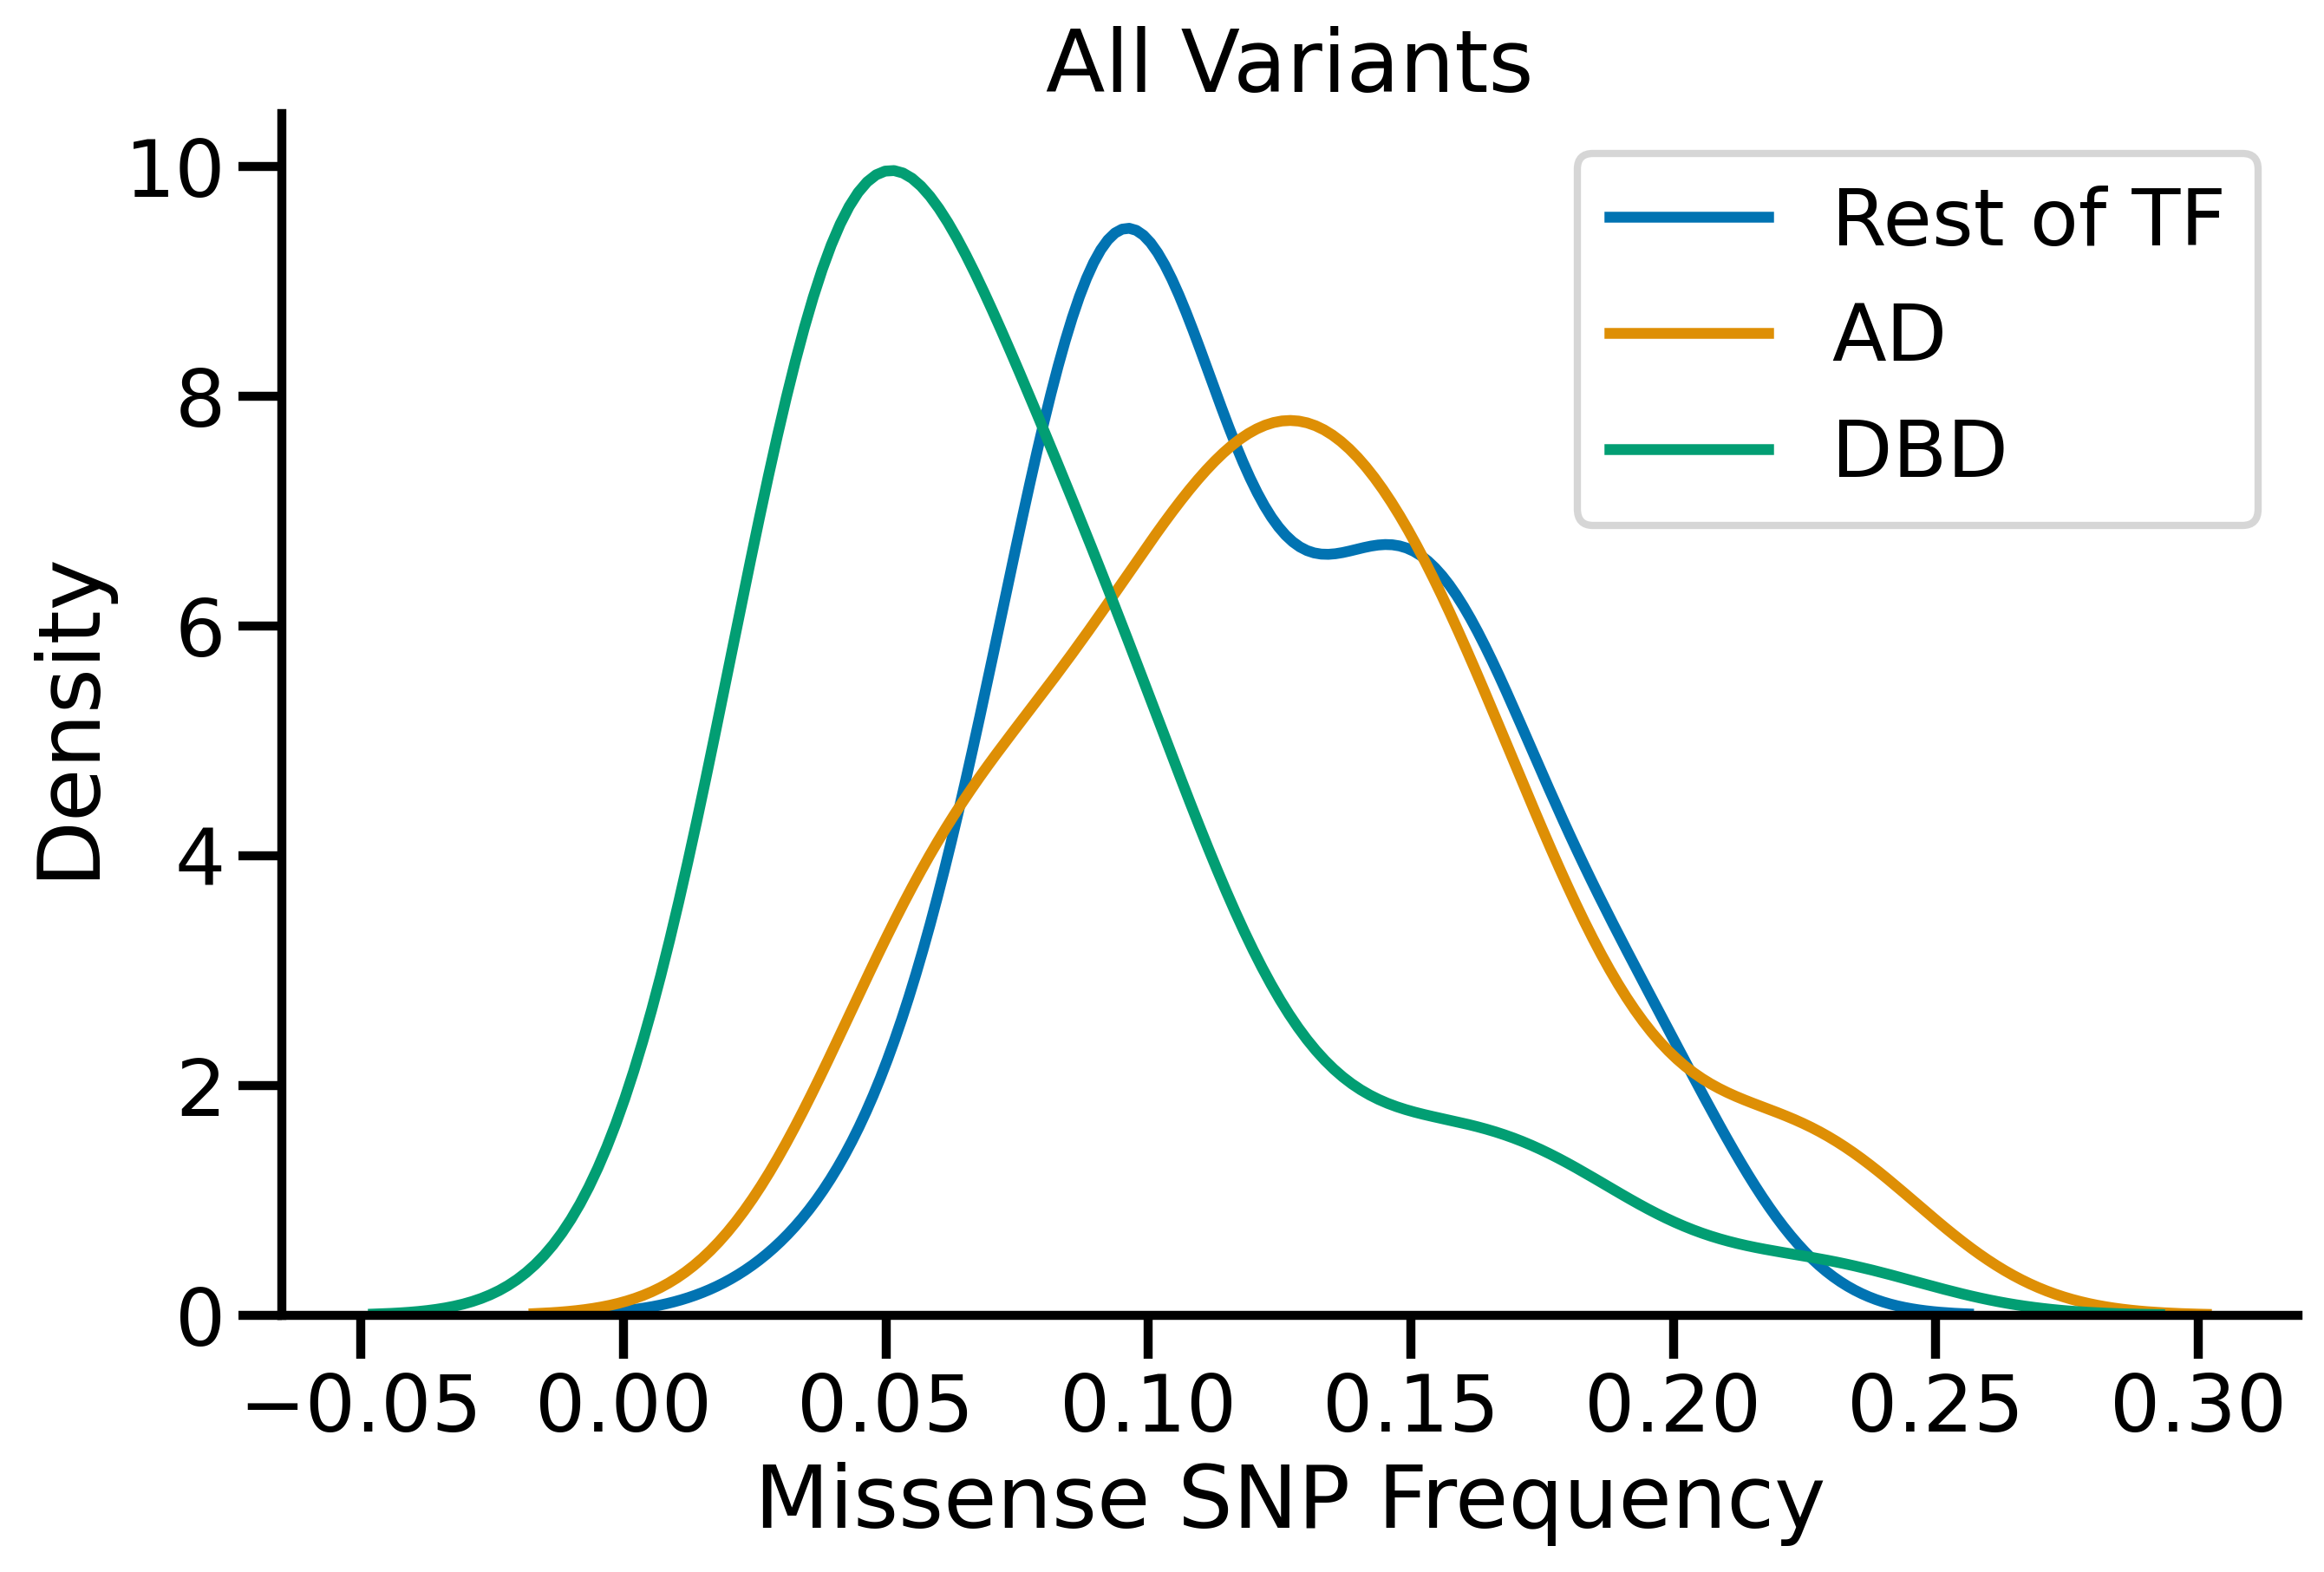

In [35]:
palette = sns.color_palette('colorblind')
sns.set_context('poster')
plt.figure(figsize = (10, 6), dpi = 300)


rest_of_TF_prop = (output["TF_missense"] - output["AD_missense"]) \
/ (output["TF_cds_length"] - output["AD_cds_length"])

sns.kdeplot(rest_of_TF_prop, label = "Rest of TF", color = palette[0]);
sns.kdeplot(output["AD_missense_prop"], color = palette[1], label = "AD");
sns.kdeplot(output["DBD_missense_prop"], color = palette[2], label = "DBD");


plt.legend()
plt.xlabel("Missense SNP Frequency")
plt.title("All Variants")
sns.despine()

In [36]:
for gene in set(contains_DBD_sig["gene-symbol"]) | set(sig_output["gene-symbol"]):
    print(gene)

MYT1L
CASZ1
RORA
YY1
GLIS1
HIVEP3
AR
ESR2
TCF7L2
OTX1
PAX6
ARNT2
ARX
KLF16
NR4A2
MEIS2
PAX5
NCOA1
TFE3
NR1D1
KDM5B
KLF7
NKX2-2
IKZF1
PITX1
MTF1
KMT2A
EGR3
CAMTA2
ERG


In [45]:
set(contains_DBD_sig["gene-symbol"]) | set(sig_output["gene-symbol"])

{'AR',
 'ARNT2',
 'ARX',
 'CAMTA2',
 'CASZ1',
 'EGR3',
 'ERG',
 'ESR2',
 'GLIS1',
 'HIVEP3',
 'IKZF1',
 'KDM5B',
 'KLF16',
 'KLF7',
 'KMT2A',
 'MEIS2',
 'MTF1',
 'MYT1L',
 'NCOA1',
 'NKX2-2',
 'NR1D1',
 'NR4A2',
 'OTX1',
 'PAX5',
 'PAX6',
 'PITX1',
 'RORA',
 'TCF7L2',
 'TFE3',
 'YY1'}

In [44]:
len(set(contains_DBD_sig["gene-symbol"]) | set(sig_output["gene-symbol"]))

30

In [49]:
set(hit_genes) - (set(contains_DBD_sig["gene-symbol"]) | set(sig_output["gene-symbol"]))

set()

In [38]:
hit_genes = [
    "TFE3", "CASZ1", "CAMTA2", "ARNT2", "YY1", "ERG", "PAX5", "MEIS2", "ESR2",
    "NR1D1", "OTX1", "PITX1", "RORA", "HIVEP3", "NKX2-2", "PAX6", "KLF7",
    "NR4A2", "AR", "KDM5B", "GLIS1", "ARX", "TCF7L2", "EGR3", "MYT1L",
    "MTF1", "IKZF1", "KLF16"
]


In [50]:
new_hit_genes = set(contains_DBD_sig["gene-symbol"]) | set(sig_output["gene-symbol"])

In [51]:
known_ADs = pd.read_csv("../../output/known_ADs_considering_isoforms_and_canonical.csv")
hit_gene_ADs = known_ADs[known_ADs["Gene"].isin(new_hit_genes)]
hit_gene_ADs = hit_gene_ADs[~hit_gene_ADs["uniprotID"].str.contains("-")]
hit_gene_ADs["AD Length"] = hit_gene_ADs["ProteinRegionSeq"].str.len()
hit_gene_ADs[["Gene", "AD Length"]].groupby("Gene")["AD Length"].apply(list).reset_index()

,Gene,AD Length
0,AR,"[494, 259]"
1,ARNT2,[194]
2,ARX,[91]
3,CAMTA2,"[184, 110]"
4,CASZ1,[155]
5,EGR3,[202]
6,ERG,"[47, 144]"
7,ESR2,"[148, 197]"
8,GLIS1,[174]
9,HIVEP3,[864]


# Summary

In [58]:
summary = output[["gene-symbol"]]
summary["AD_vs_TF_sig"] = summary["gene-symbol"].isin(sig_output["gene-symbol"])
summary["AD_vs_DBD_sig"] = summary["gene-symbol"].isin(contains_DBD_sig["gene-symbol"])
summary

/var/folders/hw/xx051vr9457c7lrngf2mypgr0000gn/T/ipykernel_81469/2989340729.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  summary["AD_vs_TF_sig"] = summary["gene-symbol"].isin(sig_output["gene-symbol"])
/var/folders/hw/xx051vr9457c7lrngf2mypgr0000gn/T/ipykernel_81469/2989340729.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  summary["AD_vs_DBD_sig"] = summary["gene-symbol"].isin(contains_DBD_sig["gene-symbol"])


,gene-symbol,AD_vs_TF_sig,AD_vs_DBD_sig
0,ARNT2,False,True
1,ARX,False,True
2,AR,False,True
3,CASZ1,True,True
4,CC2D1A,False,False
5,CAMTA2,False,True
6,EBF3,False,False
7,EGR3,False,True
8,ESR2,True,False
9,GLIS1,False,True


In [59]:
summary[summary["AD_vs_TF_sig"] | summary["AD_vs_DBD_sig"]]

,gene-symbol,AD_vs_TF_sig,AD_vs_DBD_sig
0,ARNT2,False,True
1,ARX,False,True
2,AR,False,True
3,CASZ1,True,True
5,CAMTA2,False,True
7,EGR3,False,True
8,ESR2,True,False
9,GLIS1,False,True
10,ERG,False,True
11,HIVEP3,False,True


In [60]:
summary.to_csv("../../output/iWES_v3_enrich_analysis.csv", index=False)

In [69]:
summary[summary["AD_vs_TF_sig"] | summary["AD_vs_DBD_sig"]].sort_values(by = ['AD_vs_TF_sig', 'AD_vs_DBD_sig', 'gene-symbol'], ascending=[False, False, True]).to_csv("../../output/iWES_v3_enrich_analysis_sig.csv", index=False)